In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import time


In [2]:
# --- Check for GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### Agent brain (unchanged architecture from the gaze-cooperation model)\nOnly the *input size* changes (public input grows from 5 to 7 to carry self/partner effort cost). Hidden size, heads, and everything else stays identical, which is what makes the weight-transfer loader below possible.

In [3]:
#################################################################
# 1. AGENT BRAIN CLASS (unchanged from gaze-cooperation model)
#################################################################

class AgentBrain(nn.Module):
    """
    An Actor-Critic agent with a shared RNN trunk (GRU).
    Identical to the gaze-cooperation model -- only input_size changes
    at construction time (7 public + 5 private = 12, vs. 5+5=10 before).
    """
    def __init__(self, public_input_size, private_input_size, rnn_hidden_size,
                 move_action_size, pull_action_size, gaze_action_size):

        super(AgentBrain, self).__init__()

        self.input_size = public_input_size + private_input_size
        self.rnn_hidden_size = rnn_hidden_size
        self.move_action_size = move_action_size
        self.pull_action_size = pull_action_size
        self.gaze_action_size = gaze_action_size

        # --- 1. The Shared RNN "Trunk" ---
        self.rnn_trunk = nn.GRUCell(self.input_size, self.rnn_hidden_size)

        # --- 2. The "Actor" Head ---
        self.move_head = nn.Linear(self.rnn_hidden_size, move_action_size)
        self.pull_head = nn.Linear(self.rnn_hidden_size, pull_action_size)
        self.gaze_head = nn.Linear(self.rnn_hidden_size, gaze_action_size)

        # --- 3. The "Critic" Head ---
        self.critic_head = nn.Linear(self.rnn_hidden_size, 1)

    def forward(self, public_input, private_gaze_input, prev_hidden_state, pull_mask):

        full_input = torch.cat([public_input, private_gaze_input], dim=-1)
        current_hidden_state = self.rnn_trunk(full_input, prev_hidden_state)

        value = self.critic_head(current_hidden_state)

        move_logits = self.move_head(current_hidden_state)
        gaze_logits = self.gaze_head(current_hidden_state)

        pull_logits = self.pull_head(current_hidden_state)
        pull_logits = pull_logits + pull_mask

        return (move_logits, pull_logits, gaze_logits), value, current_hidden_state


### environment: effort-inequity cooperation task
Matches the single-factor pilot design from your poster/SFARI text: **one agent's cost is fixed low, the other's varies continuously across a low-to-high range, resampled every block.** *Which* agent is fixed now also switches, mimicking the session structure from your K99 text ("the animal with the fixed force will be randomly alternated session by session").

- `SESSION_BLOCKS = 4`: matches "each session will consist of 4 blocks" -- at the start of every session, `fixed_agent` is re-randomized between `'A'`/`'B'`
- `VARYING_FORCE_RANGE = (100, 900)`: the non-fixed agent's force is resampled uniformly in this range every block, matching "force levels between 100 and 900 grams across blocks"
- Force cost is modeled as absolute lever force here, linearly mapped to RL cost -- your Fig.4 analysis actually defines cost as the *difference between the current and previous block's force* (a relative/subjective-cost framing); swap that in `_set_new_block()` below if you want to match that specific analysis later.

In [4]:
#################################################################
# 2. EFFORT-INEQUITY ENVIRONMENT (single-factor pilot design, session-structured)
#################################################################

# --- Force -> RL cost mapping ---
FORCE_LOW = 100          # grams -- the fixed agent's constant force
VARYING_FORCE_RANGE = (100, 900)   # grams -- the varying agent's per-block range
FORCE_TO_COST_SCALE = 0.3 / 900    # so 900g ~ comparable magnitude to old EFFORT_HIGH=0.3
SESSION_BLOCKS = 4        # blocks per "session" -- matches K99 text (4 blocks/session)

def force_to_cost(force_grams):
    return force_grams * FORCE_TO_COST_SCALE


class CurriculumEnv:
    def __init__(self, block_len=3000, session_blocks=SESSION_BLOCKS):
        self.pull_reset_time = 20
        self.training_phase = "SELF_REWARD"
        self.current_sync_window = 30

        # --- Gaze cost (kept from the gaze-cooperation model) ---
        self.gaze_cost = 0.0

        # --- Effort-inequity: single-factor design, session-structured ---
        self.block_len = block_len
        self.session_blocks = session_blocks
        self._effort_step_counter = 0
        self._block_counter = 0
        self.fixed_agent = None  # assigned on the first block below

        self.reset()
        self._set_new_block()

    def set_training_phase(self, phase, sync_window=30):
        self.training_phase = phase
        self.current_sync_window = sync_window
        print(f"*** ENV UPDATED: Phase={self.training_phase}, "
              f"SyncWindow={self.current_sync_window}, GazeCost={self.gaze_cost} ***")

    def _set_new_block(self):
        """
        Advances one block. At the start of every new session (every
        `session_blocks` blocks), re-randomizes which agent is fixed --
        mimicking "the animal with the fixed force will be randomly
        alternated session by session." Within a session, the fixed agent
        stays fixed at FORCE_LOW while the varying agent's force is
        resampled uniformly from VARYING_FORCE_RANGE each block.
        """
        if self._block_counter % self.session_blocks == 0:
            self.fixed_agent = np.random.choice(['A', 'B'])

        varying_force = np.random.uniform(*VARYING_FORCE_RANGE)
        if self.fixed_agent == 'A':
            self.force_A, self.force_B = FORCE_LOW, varying_force
        else:
            self.force_A, self.force_B = varying_force, FORCE_LOW

        self.cost_A = force_to_cost(self.force_A)
        self.cost_B = force_to_cost(self.force_B)
        self.cond_label = f"fixed{self.fixed_agent}_A{self.force_A:.0f}g_B{self.force_B:.0f}g"

        self._block_counter += 1

    def _get_state(self):
        on_cooldown_A = self.agent_A_pull_cooldown > 0
        is_drinking_A = self.A_is_drinking
        can_pull_A = not (on_cooldown_A or is_drinking_A)

        on_cooldown_B = self.agent_B_pull_cooldown > 0
        is_drinking_B = self.B_is_drinking
        can_pull_B = not (on_cooldown_B or is_drinking_B)

        state_A = {
            'can_pull': can_pull_A,
            'self_is_drinking': self.A_is_drinking,
            'self_on_cooldown': on_cooldown_A,
            'self_cooldown_remaining': self.agent_A_pull_cooldown,
            'self_drink_timer_remaining': self.A_drink_timer,
            'success_sound': self.success_sound_played
        }
        state_B = {
            'can_pull': can_pull_B,
            'self_is_drinking': self.B_is_drinking,
            'self_on_cooldown': on_cooldown_B,
            'self_cooldown_remaining': self.agent_B_pull_cooldown,
            'self_drink_timer_remaining': self.B_drink_timer,
            'success_sound': self.success_sound_played
        }
        return state_A, state_B

    def reset(self):
        self.current_step = 0
        self.pull_A_timestamp = -1
        self.pull_B_timestamp = -1
        self.agent_A_pull_cooldown = 0
        self.agent_B_pull_cooldown = 0
        self.success_sound_played = 0
        self.A_time_since_pull = 1000
        self.B_time_since_pull = 1000
        self.A_is_drinking = False
        self.B_is_drinking = False
        self.A_drink_timer = 0
        self.B_drink_timer = 0
        return self._get_state()

    def step(self, action_A, action_B):
        self.current_step += 1
        reward_A, reward_B = -0.01, -0.01  # base cost of living
        self.success_sound_played = 0
        done = False
        coordination_attempt_complete = False

        self.A_time_since_pull += 1
        self.B_time_since_pull += 1

        # --- Gaze cost (unchanged from gaze-cooperation model) ---
        if self.training_phase != "SELF_REWARD":
            if action_A['gaze'] == 1:
                reward_A -= self.gaze_cost
            if action_B['gaze'] == 1:
                reward_B -= self.gaze_cost

        # --- Standard timer logic ---
        on_cooldown_A = self.agent_A_pull_cooldown > 0
        is_drinking_A = self.A_is_drinking
        can_pull_A = not (on_cooldown_A or is_drinking_A)

        on_cooldown_B = self.agent_B_pull_cooldown > 0
        is_drinking_B = self.B_is_drinking
        can_pull_B = not (on_cooldown_B or is_drinking_B)

        if self.A_drink_timer > 0:
            self.A_drink_timer -= 1
            if self.A_drink_timer == 0: self.A_is_drinking = False
        if self.B_drink_timer > 0:
            self.B_drink_timer -= 1
            if self.B_drink_timer == 0: self.B_is_drinking = False
        if self.agent_A_pull_cooldown > 0: self.agent_A_pull_cooldown -= 1
        if self.agent_B_pull_cooldown > 0: self.agent_B_pull_cooldown -= 1

        # --- Effort cost on ATTEMPTED pulls (mask-permitting) ---
        if action_A['pull'] == 1 and can_pull_A:
            reward_A -= self.cost_A
        if action_B['pull'] == 1 and can_pull_B:
            reward_B -= self.cost_B

        if self.training_phase == "SELF_REWARD":
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0; reward_A += 15.0; self.success_sound_played = 1
                self.agent_A_pull_cooldown = self.pull_reset_time
                self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0; reward_B += 15.0; self.success_sound_played = 1
                self.agent_B_pull_cooldown = self.pull_reset_time
                self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)

        else:  # COOP_ASSISTED or COOP_FULL
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0
                self.pull_A_timestamp = self.current_step
                self.agent_A_pull_cooldown = self.pull_reset_time
                if self.pull_B_timestamp != -1: coordination_attempt_complete = True

            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0
                self.pull_B_timestamp = self.current_step
                self.agent_B_pull_cooldown = self.pull_reset_time
                if self.pull_A_timestamp != -1: coordination_attempt_complete = True

            if coordination_attempt_complete:
                if abs(self.pull_A_timestamp - self.pull_B_timestamp) <= self.current_sync_window:
                    reward_A += 15.0; reward_B += 15.0
                    self.success_sound_played = 1
                    self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
                    self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)
                else:
                    if self.training_phase == "COOP_ASSISTED": reward_A += 5.0; reward_B += 5.0
                    else: reward_A -= 0.5; reward_B -= 0.5
                self.pull_A_timestamp = -1
                self.pull_B_timestamp = -1

        # --- Advance effort block (and, every session_blocks blocks, re-flip fixed_agent) ---
        self._effort_step_counter += 1
        if self._effort_step_counter % self.block_len == 0:
            self._set_new_block()

        next_state_A, next_state_B = self._get_state()
        return next_state_A, next_state_B, reward_A, reward_B, done


### helper functions\n`get_private_state`, `calculate_gae`, `sample_actions` are unchanged from the gaze-cooperation model. `preprocess_state` is replaced with `preprocess_state_with_effort`, which appends normalized self/partner effort cost to the public vector.

In [5]:
#################################################################
# 3. HELPER FUNCTIONS
#################################################################

def preprocess_state_with_effort(state_dict, self_force, partner_force):
    """
    Public input, now size 7: the original 5 dims + normalized self_force + partner_force.

    IMPORTANT: this takes FORCE (grams), not cost, and normalizes it directly
    to [0, 1] via (force - FORCE_LOW) / (VARYING_FORCE_RANGE[1] - FORCE_LOW).
    The fixed agent (always FORCE_LOW=100g) gets exactly 0.0; the varying
    agent ranges continuously from 0.0 (at 100g) to 1.0 (at 900g).

    BUG HISTORY: earlier version passed COST and binarized it
    (`1.0 if cost > 0 else 0.0`) -- that made sense for the old discrete
    EFFORT_LOW=0.0/EFFORT_HIGH=0.3 design, but broke silently once
    FORCE_LOW became 100g (never zero): self_cost was ALWAYS > 0, so the
    network received a constant 1.0 regardless of actual force, and had
    NO information to condition behavior on. This fix restores that signal.
    """
    is_drinking = torch.tensor([1.0 if state_dict['self_is_drinking'] else 0.0])
    can_pull = torch.tensor([1.0 if state_dict['can_pull'] else 0.0])
    success_sound = torch.tensor([1.0 if state_dict['success_sound'] else 0.0])
    drink_timer = torch.tensor([state_dict['self_drink_timer_remaining'] / 50.0])
    cooldown_timer = torch.tensor([state_dict['self_cooldown_remaining'] / 20.0])

    force_range = VARYING_FORCE_RANGE[1] - FORCE_LOW  # = 800
    self_force_norm = torch.tensor([np.clip((self_force - FORCE_LOW) / force_range, 0.0, 1.0)])
    partner_force_norm = torch.tensor([np.clip((partner_force - FORCE_LOW) / force_range, 0.0, 1.0)])

    tensor_state = torch.cat([
        is_drinking, can_pull, success_sound, drink_timer, cooldown_timer,
        self_force_norm, partner_force_norm
    ], dim=0)

    return tensor_state.float().unsqueeze(0).to(device)


def get_private_state(partner_state_dict, partner_time, sync_window, reliability_level, is_gazing):
    """
    Unchanged from the gaze-cooperation model. Gaze-gated noisy readout of
    partner state. Reliability is held FIXED (not swept) during effort
    training -- see hyperparameters cell -- to avoid conflating two sources
    of task difficulty at once.
    """
    if partner_state_dict['can_pull']:
        true_mean = 1.0
    else:
        true_mean = 0.0

    base_noise = 0.6
    current_sigma = base_noise / (reliability_level + 1e-2)

    if is_gazing:
        observed_value = np.random.normal(loc=true_mean, scale=current_sigma)
        valid_bit = 1.0
    else:
        observed_value = 0.0
        valid_bit = 0.0

    p_signal = torch.tensor([observed_value])
    p_time = torch.tensor([min(partner_time / sync_window, 1.0)])
    p_drink = torch.tensor([1.0 if partner_state_dict['self_is_drinking'] else 0.0])
    p_cool = torch.tensor([1.0 if partner_state_dict['self_on_cooldown'] else 0.0])
    v_bit = torch.tensor([valid_bit])

    tensor_state = torch.cat([p_signal, p_time, p_drink, p_cool, v_bit], dim=0)
    return tensor_state.float().unsqueeze(0).to(device)


def calculate_gae(rewards, values, next_value, gamma=0.99, lambda_=0.95):
    gae = 0
    returns = []
    values = values + [next_value]
    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1] - values[step]
        gae = delta + gamma * lambda_ * gae
        returns.insert(0, gae + values[step])
    return torch.cat(returns).view(-1).float().to(device)


def sample_actions(logits_tuple):
    move_logits, pull_logits, gaze_logits = logits_tuple

    move_dist = Categorical(logits=move_logits)
    move_action = move_dist.sample()
    move_log_prob = move_dist.log_prob(move_action)

    pull_dist = Categorical(logits=pull_logits)
    pull_action = pull_dist.sample()
    pull_log_prob = pull_dist.log_prob(pull_action)

    gaze_dist = Categorical(logits=gaze_logits)
    gaze_action = gaze_dist.sample()
    gaze_log_prob = gaze_dist.log_prob(gaze_action)

    total_log_prob = move_log_prob + pull_log_prob + gaze_log_prob

    actions_dict = {
        'move': move_action.item(),
        'pull': pull_action.item(),
        'gaze': gaze_action.item()
    }
    return actions_dict, total_log_prob

### weight transfer: load the gaze-cooperation generalist checkpoint into the wider effort model\nOnly `rnn_trunk.weight_ih` changes shape (input size 10 -> 12). Everything else (recurrent weights, biases, all four output heads) transfers directly since those only depend on `hidden_size`, which is unchanged.\n\n**Path note:** this notebook lives in `MARL_effort_based_cooperation/`, while the source checkpoints live in `MARL_gaze_accumulation_strategies/training_withGAE_PPO_fixedPullCoolTime/`. The path below is a **relative** reference between those two sibling folders -- adjust `OLD_CHECKPOINT_DIR` if your actual folder depth differs, or point it at a local copy if you'd rather not depend on the sibling folder (safer for sbatch jobs, since working directory at submission time isn't always what you expect).

In [8]:
#################################################################
# 4. WEIGHT TRANSFER
#################################################################

OLD_CHECKPOINT_DIR = "/gpfs/radev/home/ws523/marmoset_tracking_DLCv2/following_up_analysis"+\
"/MARL_gaze_accumulation_strategies/training_withGAE_PPO_fixedPullCoolTime"
OLD_PUBLIC_INPUT_SIZE = 5
OLD_PRIVATE_INPUT_SIZE = 5

def load_and_expand_agent(new_model, old_checkpoint_path,
                           old_public_size=OLD_PUBLIC_INPUT_SIZE,
                           old_private_size=OLD_PRIVATE_INPUT_SIZE,
                           new_public_size=7,
                           new_private_size=5):
    old_state = torch.load(old_checkpoint_path, map_location='cpu')
    new_state = new_model.state_dict()

    for key, old_tensor in old_state.items():
        if key == 'rnn_trunk.weight_ih':
            new_tensor = new_state[key].clone()  # random init for new columns
            new_tensor[:, :old_public_size] = old_tensor[:, :old_public_size]
            new_tensor[:, new_public_size:new_public_size + old_private_size] = \
                old_tensor[:, old_public_size:old_public_size + old_private_size]
            new_state[key] = new_tensor
            print(f"Expanded '{key}': {tuple(old_tensor.shape)} -> {tuple(new_tensor.shape)} "
                  f"(effort-cost columns randomly initialized)")
        else:
            new_state[key] = old_tensor

    new_model.load_state_dict(new_state)
    print(f"Loaded and expanded weights from {old_checkpoint_path}")
    return new_model


### training hyperparameters

In [9]:
#################################################################
# 5. TRAINING HYPERPARAMETERS
#################################################################

RNN_HIDDEN_SIZE = 128
PUBLIC_INPUT_SIZE = 7    # 5 original + self_cost + partner_cost
PRIVATE_INPUT_SIZE = 5   # unchanged

MOVE_ACTIONS = 5
PULL_ACTIONS = 2
GAZE_ACTIONS = 2

TARGET_WINDOW = 10        # keep the "1s" sync window from the trained base
FIXED_RELIABILITY = 1.0   # held fixed during effort training -- see note above
BLOCK_LEN = 3000          # steps per effort contingency block (~6 rollouts)

LR_FINE_TUNE = 5e-5       # matches your other continue_training_* fine-tunes
GAMMA = 0.99
N_STEPS = 500
CONTINUE_STEPS = 800000   # starting point -- extend if behavior hasn't stabilized
ENTROPY_COEF = 0.0001
VALUE_LOSS_COEF = 0.1
EPS_CLIP = 0.2

GAZE_COST = 0.2   # carried over from the efficient/generalist gaze model


### run the training with different sensitivity to the effort level to figure out the best choice

In [10]:
"""
Cost-scale sweep: runs several SHORT fine-tunes (not the full 800k) at
different FORCE_TO_COST_SCALE multipliers, to find the smallest scale where
attempt rate actually starts responding to own cost -- before spending a
full training run on a scale that might still be too weak.

Requires: AgentBrain, CurriculumEnv, preprocess_state_with_effort,
get_private_state, calculate_gae, sample_actions, load_and_expand_agent,
and the hyperparameter constants already defined earlier in the notebook.
Paste this in a new cell after the main training-loop cell.
"""

import copy

SWEEP_STEPS = 100000          # short probe run, not the full 800k
# SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 16.0, 20.0, 25.0]   # wider range this time
SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 25.0]
BASE_SCALE = 0.3 / 900          # current value, for reference
CHECKPOINT_SET = "generalist_withGAE_PPO"   # switched from "generalist_withGAE_PPO" or "efficient_expert"


def run_short_probe(cost_scale_multiplier, n_steps=SWEEP_STEPS, seed=None):
    """
    Runs a short fine-tune at a given cost-scale multiplier and returns
    the correlation between own force and own attempt rate, plus overall
    conditional attempt rate -- both computed only over ELIGIBLE steps.

    seed: if given, sets np.random and torch seeds at the start so this
    specific replicate is reproducible. Different seeds give independent
    replicates of the same multiplier, for checking whether an effect is
    real or just run-to-run noise.
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    global FORCE_TO_COST_SCALE
    FORCE_TO_COST_SCALE = BASE_SCALE * cost_scale_multiplier

    env = CurriculumEnv(block_len=BLOCK_LEN)
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW)
    env.gaze_cost = GAZE_COST

    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_A = load_and_expand_agent(agent_A, f"{OLD_CHECKPOINT_DIR}/agent_A_{CHECKPOINT_SET}.pth")
    agent_B = load_and_expand_agent(agent_B, f"{OLD_CHECKPOINT_DIR}/agent_B_{CHECKPOINT_SET}.pth")

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state_with_effort(state_A_dict, env.force_A, env.force_B)
    public_B = preprocess_state_with_effort(state_B_dict, env.force_B, env.force_A)
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    log = []

    for update_step in range(n_steps // N_STEPS):
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []

        start_hidden_A, start_hidden_B = hidden_A.detach(), hidden_B.detach()
        hidden_A, hidden_B = start_hidden_A, start_hidden_B

        for _ in range(N_STEPS):
            mask_A = torch.tensor([[0., 0. if state_A_dict['can_pull'] else -1e9]], device=device).float()
            mask_B = torch.tensor([[0., 0. if state_B_dict['can_pull'] else -1e9]], device=device).float()

            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            with torch.no_grad():
                logits_A, value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                logits_B, value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)

            act_A, log_prob_A = sample_actions(logits_A)
            act_B, log_prob_B = sample_actions(logits_B)
            mem_act_A.append(act_A); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            force_A_now, force_B_now = env.force_A, env.force_B
            can_pull_A_now, can_pull_B_now = state_A_dict['can_pull'], state_B_dict['can_pull']
            next_A, next_B, r_A, r_B, done = env.step(act_A, act_B)
            mem_rew_A.append(r_A); mem_rew_B.append(r_B)

            log.append({'force_A': force_A_now, 'force_B': force_B_now,
                        'A_pull': act_A['pull'], 'B_pull': act_B['pull'],
                        'can_pull_A': can_pull_A_now, 'can_pull_B': can_pull_B_now})

            private_A = get_private_state(next_B, env.B_time_since_pull, env.current_sync_window, FIXED_RELIABILITY, act_A['gaze']==1)
            private_B = get_private_state(next_A, env.A_time_since_pull, env.current_sync_window, FIXED_RELIABILITY, act_B['gaze']==1)
            public_A = preprocess_state_with_effort(next_A, env.force_A, env.force_B)
            public_B = preprocess_state_with_effort(next_B, env.force_B, env.force_A)
            state_A_dict, state_B_dict = next_A, next_B

        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)
        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A)
        returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)
        values_A_old = torch.cat(mem_val_A).view(-1)
        values_B_old = torch.cat(mem_val_B).view(-1)
        adv_A = (returns_A - values_A_old); adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (returns_B - values_B_old); adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)

        curr_hidden_A, curr_hidden_B = start_hidden_A, start_hidden_B
        new_lp_A_list, new_lp_B_list = [], []
        for t in range(N_STEPS):
            (l_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            m,p,g = l_A; a = mem_act_A[t]
            new_lp_A_list.append(Categorical(logits=m).log_prob(torch.tensor(a['move']).to(device)) +
                                  Categorical(logits=p).log_prob(torch.tensor(a['pull']).to(device)) +
                                  Categorical(logits=g).log_prob(torch.tensor(a['gaze']).to(device)))
            (l_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            m,p,g = l_B; a = mem_act_B[t]
            new_lp_B_list.append(Categorical(logits=m).log_prob(torch.tensor(a['move']).to(device)) +
                                  Categorical(logits=p).log_prob(torch.tensor(a['pull']).to(device)) +
                                  Categorical(logits=g).log_prob(torch.tensor(a['gaze']).to(device)))

        new_lp_A = torch.stack(new_lp_A_list).view(-1); old_lp_A = torch.cat(mem_logp_A).detach().view(-1)
        new_lp_B = torch.stack(new_lp_B_list).view(-1); old_lp_B = torch.cat(mem_logp_B).detach().view(-1)

        ratio_A = torch.exp(new_lp_A - old_lp_A)
        loss_A = -torch.min(ratio_A*adv_A, torch.clamp(ratio_A,1-EPS_CLIP,1+EPS_CLIP)*adv_A).mean() + \
                 VALUE_LOSS_COEF*F.mse_loss(values_A_old, returns_A)
        ratio_B = torch.exp(new_lp_B - old_lp_B)
        loss_B = -torch.min(ratio_B*adv_B, torch.clamp(ratio_B,1-EPS_CLIP,1+EPS_CLIP)*adv_B).mean() + \
                 VALUE_LOSS_COEF*F.mse_loss(values_B_old, returns_B)

        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()

        if update_step % (5000 // N_STEPS) == 0:
            steps_so_far = update_step * N_STEPS
            seed_tag = f" seed={seed}" if seed is not None else ""
            print(f"    [scale x{cost_scale_multiplier}{seed_tag}] step {steps_so_far}/{n_steps}, "
                  f"R_A: {sum(mem_rew_A):.2f}, R_B: {sum(mem_rew_B):.2f}")

    log_df = pd.DataFrame(log)
    # Only correlate on steps where the agent was actually ELIGIBLE to pull --
    # steps where pull is masked (on cooldown/drinking) are forced to 0
    # regardless of policy, and dilute any real cost-sensitivity signal since
    # they're the majority of steps.
    eligible_A = log_df[log_df['can_pull_A']]
    eligible_B = log_df[log_df['can_pull_B']]
    corr_A = eligible_A['force_A'].corr(eligible_A['A_pull'])
    corr_B = eligible_B['force_B'].corr(eligible_B['B_pull'])
    pct_eligible_A = log_df['can_pull_A'].mean()
    pct_eligible_B = log_df['can_pull_B'].mean()
    attempt_rate_A = eligible_A['A_pull'].mean()
    attempt_rate_B = eligible_B['B_pull'].mean()
    return corr_A, corr_B, pct_eligible_A, pct_eligible_B, attempt_rate_A, attempt_rate_B, log_df


SWEEP_RESULTS_OUT = f"cost_scale_sweep_results_{CHECKPOINT_SET}.pkl"
N_REPLICATES = 3            # independent seeds per multiplier
SEED_LIST = list(range(N_REPLICATES))   # [0, 1, 2] -- change if you want specific seeds


def run_cost_scale_sweep(force_retrain=False, n_replicates=N_REPLICATES, seeds=None):
    """
    force_retrain=False (default): if results already exist, skip and print them.
    force_retrain=True: always re-run everything, overwriting existing outputs.

    Runs `n_replicates` independent seeds per multiplier and reports mean +/- std,
    so we can tell a real cost effect apart from run-to-run noise (which is what
    the single-seed x1/x3/x5/x8 run earlier likely was).
    """
    seeds = seeds if seeds is not None else SEED_LIST[:n_replicates]

    if not force_retrain and os.path.exists(SWEEP_RESULTS_OUT):
        print(f"Found existing {SWEEP_RESULTS_OUT} -- loading instead of re-running.")
        print("Call run_cost_scale_sweep(force_retrain=True) to redo the sweep.\n")
        results_df = pd.read_pickle(SWEEP_RESULTS_OUT)
        print(results_df.to_string(index=False))
        return results_df

    if force_retrain and os.path.exists(SWEEP_RESULTS_OUT):
        print(f"force_retrain=True -- overwriting existing {SWEEP_RESULTS_OUT}\n")

    print(f"Running {len(SWEEP_SCALES)} multipliers x {len(seeds)} seeds each "
          f"({len(SWEEP_SCALES)*len(seeds)} total probes, checkpoint={CHECKPOINT_SET})\n")

    raw_results = []
    for mult in SWEEP_SCALES:
        for seed in seeds:
            print(f"\n=== multiplier x{mult}, seed {seed} ({SWEEP_STEPS} steps) ===")
            corr_A, corr_B, pct_elig_A, pct_elig_B, atr_A, atr_B, log_df = \
                run_short_probe(mult, seed=seed)
            max_cost = BASE_SCALE * mult * 900
            raw_results.append({
                'multiplier': mult, 'seed': seed, 'max_cost': max_cost,
                'corr_A': corr_A, 'corr_B': corr_B,
                'pct_eligible_A': pct_elig_A, 'pct_eligible_B': pct_elig_B,
                'attempt_rate_A': atr_A, 'attempt_rate_B': atr_B,
            })
            log_df.to_pickle(f"cost_scale_sweep_rawlog_{CHECKPOINT_SET}_x{mult}_seed{seed}.pkl")

    raw_df = pd.DataFrame(raw_results)
    raw_df.to_pickle(f"cost_scale_sweep_rawresults_{CHECKPOINT_SET}.pkl")

    # --- Aggregate across seeds: mean +/- std per multiplier ---
    agg = raw_df.groupby('multiplier').agg(
        max_cost=('max_cost', 'first'),
        corr_A_mean=('corr_A', 'mean'), corr_A_std=('corr_A', 'std'),
        corr_B_mean=('corr_B', 'mean'), corr_B_std=('corr_B', 'std'),
        attempt_rate_A_mean=('attempt_rate_A', 'mean'), attempt_rate_A_std=('attempt_rate_A', 'std'),
        attempt_rate_B_mean=('attempt_rate_B', 'mean'), attempt_rate_B_std=('attempt_rate_B', 'std'),
    ).reset_index()

    print("\n" + "="*100)
    print(f"AGGREGATED OVER {len(seeds)} SEEDS ({CHECKPOINT_SET}):")
    print(agg.to_string(index=False))
    print("="*100)
    print("Look for attempt_rate_A/B_mean trending DOWN as multiplier increases, with")
    print("std small enough that the trend is bigger than the noise -- that's the")
    print("real test now, rather than a single noisy correlation value per multiplier.")

    agg.to_pickle(SWEEP_RESULTS_OUT)
    print(f"\nSaved {SWEEP_RESULTS_OUT} (aggregated) and "
          f"cost_scale_sweep_rawresults_{CHECKPOINT_SET}.pkl (per-seed)")
    return agg


# --- To run the sweep ---
# run_cost_scale_sweep()                                # skips if results already exist
# run_cost_scale_sweep(force_retrain=True)               # always re-runs, 3 seeds/multiplier
# run_cost_scale_sweep(force_retrain=True, n_replicates=5, seeds=[0,1,2,3,4])  # more replicates
results_df = run_cost_scale_sweep()
# results_df = run_cost_scale_sweep(force_retrain=True) 

Found existing cost_scale_sweep_results_generalist_withGAE_PPO.pkl -- loading instead of re-running.
Call run_cost_scale_sweep(force_retrain=True) to redo the sweep.

 multiplier  max_cost  corr_A_mean  corr_A_std  corr_B_mean  corr_B_std  attempt_rate_A_mean  attempt_rate_A_std  attempt_rate_B_mean  attempt_rate_B_std
        1.0       0.3     0.023431    0.030515    -0.025244         NaN             0.260738            0.027213             0.999874            0.000219
        3.0       0.9     0.024540    0.045950    -0.002652    0.025718             0.251425            0.012379             0.999749            0.000218
        5.0       1.5    -0.015866    0.066373    -0.021549    0.015854             0.255382            0.019472             0.999747            0.000219
        8.0       2.4     0.007317    0.039000    -0.017060    0.026329             0.253715            0.000722             0.999747            0.000219
       12.0       3.6     0.001437    0.029096    -0.026796    

Multiplier |  Attempt rate A (mean +/- std) |  Attempt rate B (mean +/- std)
       1.0 |             0.2607 +/- 0.0222    |             0.9999 +/- 0.0002   
       3.0 |             0.2514 +/- 0.0101    |             0.9997 +/- 0.0002   
       5.0 |             0.2554 +/- 0.0159    |             0.9997 +/- 0.0002   
       8.0 |             0.2537 +/- 0.0006    |             0.9997 +/- 0.0002   
      12.0 |             0.2637 +/- 0.0206    |             0.9997 +/- 0.0002   
      25.0 |             0.2192 +/- 0.0121    |             0.9995 +/- 0.0005   

Saved attempt_rate_ceiling_check_generalist_withGAE_PPO.pdf

Shaded bands = +/- 1 std across seeds. If bands are wide relative to the
gap between multiplier lines, differences between cost levels aren't
distinguishable from run-to-run noise yet. If all lines/bands sit near 1.0
regardless of force or multiplier, that confirms the ceiling-effect
explanation: agents attempt on essentially every eligible step no matter
the cost, because

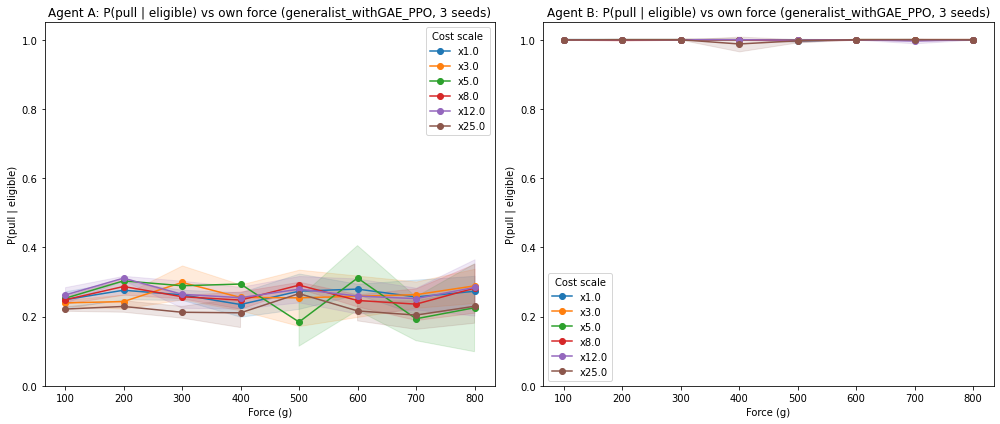

In [15]:
"""
Plots raw conditional attempt rate (P(pull | eligible)) vs. force, one line
per cost-scale multiplier, using the raw per-seed logs already saved by the
sweep -- no retraining needed. Updated to match the new sweep:
  - CHECKPOINT_SET-aware filenames
  - wider SWEEP_SCALES range
  - multiple seeds per multiplier -> plots mean with a shaded std band
    across seeds, and prints mean +/- std for the overall attempt rate.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CHECKPOINT_SET = "generalist_withGAE_PPO"  # "generalist_withGAE_PPO" or "efficient_expert"
# SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 16.0, 20.0, 25.0]   # wider range this time
SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 25.0]
SEED_LIST = [0, 1, 2]   # match N_REPLICATES / seeds used in the sweep

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

print(f"{'Multiplier':>10} | {'Attempt rate A (mean +/- std)':>30} | {'Attempt rate B (mean +/- std)':>30}")

for mult in SWEEP_SCALES:
    # --- Load all seeds for this multiplier ---
    per_seed_overall_A, per_seed_overall_B = [], []
    per_seed_binned_A, per_seed_binned_B = [], []

    for seed in SEED_LIST:
        fname = f"cost_scale_sweep_rawlog_{CHECKPOINT_SET}_x{mult}_seed{seed}.pkl"
        try:
            log_df = pd.read_pickle(fname)
        except FileNotFoundError:
            print(f"  (missing {fname}, skipping this seed)")
            continue

        elig_A = log_df[log_df['can_pull_A']].copy()
        elig_B = log_df[log_df['can_pull_B']].copy()

        per_seed_overall_A.append(elig_A['A_pull'].mean())
        per_seed_overall_B.append(elig_B['B_pull'].mean())

        elig_A['force_bin'] = (elig_A['force_A'] // 100) * 100
        elig_B['force_bin'] = (elig_B['force_B'] // 100) * 100
        per_seed_binned_A.append(elig_A.groupby('force_bin')['A_pull'].mean())
        per_seed_binned_B.append(elig_B.groupby('force_bin')['B_pull'].mean())

    if not per_seed_overall_A:
        print(f"{mult:>10} | {'NO DATA':>30} | {'NO DATA':>30}")
        continue

    mean_A, std_A = np.mean(per_seed_overall_A), np.std(per_seed_overall_A)
    mean_B, std_B = np.mean(per_seed_overall_B), np.std(per_seed_overall_B)
    print(f"{mult:>10} | {mean_A:>18.4f} +/- {std_A:<9.4f} | {mean_B:>18.4f} +/- {std_B:<9.4f}")

    # --- Average the binned curves across seeds (align on force_bin index) ---
    binned_A_df = pd.concat(per_seed_binned_A, axis=1)
    binned_B_df = pd.concat(per_seed_binned_B, axis=1)
    mean_curve_A, std_curve_A = binned_A_df.mean(axis=1), binned_A_df.std(axis=1)
    mean_curve_B, std_curve_B = binned_B_df.mean(axis=1), binned_B_df.std(axis=1)

    line_A, = axes[0].plot(mean_curve_A.index, mean_curve_A.values, 'o-', label=f'x{mult}')
    axes[0].fill_between(mean_curve_A.index, mean_curve_A.values - std_curve_A.values,
                          mean_curve_A.values + std_curve_A.values, alpha=0.15, color=line_A.get_color())

    line_B, = axes[1].plot(mean_curve_B.index, mean_curve_B.values, 'o-', label=f'x{mult}')
    axes[1].fill_between(mean_curve_B.index, mean_curve_B.values - std_curve_B.values,
                          mean_curve_B.values + std_curve_B.values, alpha=0.15, color=line_B.get_color())

axes[0].set_title(f"Agent A: P(pull | eligible) vs own force ({CHECKPOINT_SET}, {len(SEED_LIST)} seeds)")
axes[0].set_xlabel("Force (g)")
axes[0].set_ylabel("P(pull | eligible)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Cost scale")

axes[1].set_title(f"Agent B: P(pull | eligible) vs own force ({CHECKPOINT_SET}, {len(SEED_LIST)} seeds)")
axes[1].set_xlabel("Force (g)")
axes[1].set_ylabel("P(pull | eligible)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="Cost scale")

plt.tight_layout()
plt.savefig(f"attempt_rate_ceiling_check_{CHECKPOINT_SET}.pdf", dpi=150)
print(f"\nSaved attempt_rate_ceiling_check_{CHECKPOINT_SET}.pdf")
print("\nShaded bands = +/- 1 std across seeds. If bands are wide relative to the")
print("gap between multiplier lines, differences between cost levels aren't")
print("distinguishable from run-to-run noise yet. If all lines/bands sit near 1.0")
print("regardless of force or multiplier, that confirms the ceiling-effect")
print("explanation: agents attempt on essentially every eligible step no matter")
print("the cost, because a missed attempt guarantees zero reward while an attempt")
print("only risks a modest cost against a much larger potential payoff.")

Multiplier |   Mean IPI A (steps, mean +/- std) |   Mean IPI B (steps, mean +/- std)
       1.0 |                  42.44 +/- 0.25    |                  37.88 +/- 0.27   
       3.0 |                  42.49 +/- 0.09    |                  37.68 +/- 0.16   
       5.0 |                  42.49 +/- 0.32    |                  37.86 +/- 0.12   
       8.0 |                  42.66 +/- 0.19    |                  37.94 +/- 0.24   
      12.0 |                  42.31 +/- 0.60    |                  37.70 +/- 0.24   
      25.0 |                  43.15 +/- 0.32    |                  37.81 +/- 0.15   

Saved ipi_vs_force_generalist_withGAE_PPO.pdf

If IPI increases with force (agent takes longer between pulls as its own
cost rises), that's cost-sensitivity showing up in TIMING rather than in
raw attempt rate -- a real effect the eligible-attempt-rate metric would miss.
Note: B's ~1.0 attempt rate means B pulls almost every eligible step, so its
IPI is mechanically close to the cooldown/drink-timer c

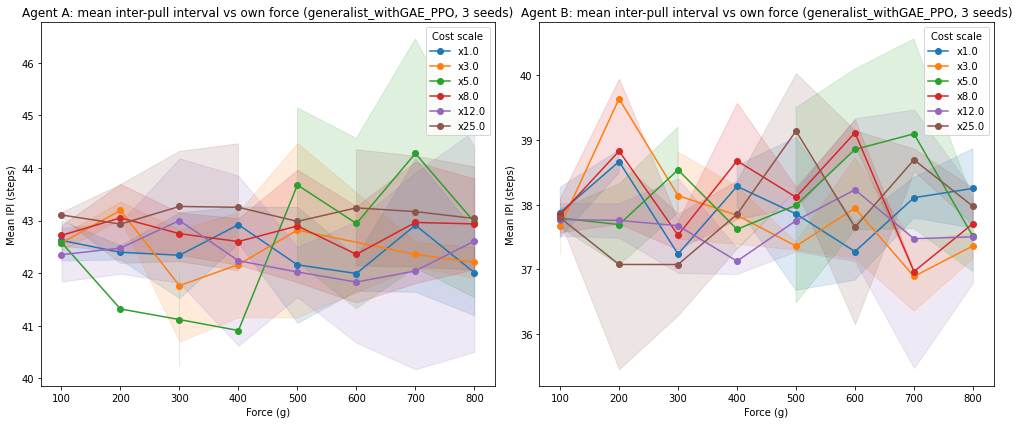

In [16]:
"""
Inter-pull-interval (IPI) vs. own force, by cost-scale multiplier.
Uses the raw per-step sweep logs already saved -- no retraining needed.

Rationale: attempt-rate-per-eligible-step only captures whether an agent
ever pulls, not WHEN. A cost-sensitive strategy could show up as "pull less
promptly" (longer gaps between pulls) rather than "pull less often" -- this
would be invisible to the attempt-rate metric but visible here.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CHECKPOINT_SET = "generalist_withGAE_PPO"  # "generalist_withGAE_PPO" or "efficient_expert"
# SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 16.0, 20.0, 25.0]   # match the full sweep, not the trimmed plot
SWEEP_SCALES = [1.0, 3.0, 5.0, 8.0, 12.0, 25.0]
SEED_LIST = [0, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

print(f"{'Multiplier':>10} | {'Mean IPI A (steps, mean +/- std)':>34} | {'Mean IPI B (steps, mean +/- std)':>34}")

for mult in SWEEP_SCALES:
    per_seed_overall_ipi_A, per_seed_overall_ipi_B = [], []
    per_seed_binned_ipi_A, per_seed_binned_ipi_B = [], []

    for seed in SEED_LIST:
        fname = f"cost_scale_sweep_rawlog_{CHECKPOINT_SET}_x{mult}_seed{seed}.pkl"
        try:
            log_df = pd.read_pickle(fname)
        except FileNotFoundError:
            print(f"  (missing {fname}, skipping this seed)")
            continue

        for agent, pull_col, can_pull_col, force_col, overall_list, binned_list in [
            ('A', 'A_pull', 'can_pull_A', 'force_A', per_seed_overall_ipi_A, per_seed_binned_ipi_A),
            ('B', 'B_pull', 'can_pull_B', 'force_B', per_seed_overall_ipi_B, per_seed_binned_ipi_B),
        ]:
            # Actual executed pulls: action==1 AND eligible (mask allowed it through)
            pull_idx = log_df.index[(log_df[pull_col] == 1) & (log_df[can_pull_col])].to_numpy()
            if len(pull_idx) < 2:
                continue

            ipi = np.diff(pull_idx)  # steps between consecutive pulls
            overall_list.append(ipi.mean())

            # Bin each IPI by the force active at the START of that interval
            force_at_start = log_df.loc[pull_idx[:-1], force_col].to_numpy()
            ipi_df = pd.DataFrame({'force_bin': (force_at_start // 100) * 100, 'ipi': ipi})
            binned_list.append(ipi_df.groupby('force_bin')['ipi'].mean())

    if not per_seed_overall_ipi_A:
        print(f"{mult:>10} | {'NO DATA':>34} | {'NO DATA':>34}")
        continue

    mean_A, std_A = np.mean(per_seed_overall_ipi_A), np.std(per_seed_overall_ipi_A)
    mean_B, std_B = (np.mean(per_seed_overall_ipi_B), np.std(per_seed_overall_ipi_B)) \
        if per_seed_overall_ipi_B else (np.nan, np.nan)
    print(f"{mult:>10} | {mean_A:>22.2f} +/- {std_A:<7.2f} | {mean_B:>22.2f} +/- {std_B:<7.2f}")

    if per_seed_binned_ipi_A:
        binned_A_df = pd.concat(per_seed_binned_ipi_A, axis=1)
        mean_curve_A, std_curve_A = binned_A_df.mean(axis=1), binned_A_df.std(axis=1)
        line_A, = axes[0].plot(mean_curve_A.index, mean_curve_A.values, 'o-', label=f'x{mult}')
        axes[0].fill_between(mean_curve_A.index, mean_curve_A.values - std_curve_A.values,
                              mean_curve_A.values + std_curve_A.values, alpha=0.15, color=line_A.get_color())

    if per_seed_binned_ipi_B:
        binned_B_df = pd.concat(per_seed_binned_ipi_B, axis=1)
        mean_curve_B, std_curve_B = binned_B_df.mean(axis=1), binned_B_df.std(axis=1)
        line_B, = axes[1].plot(mean_curve_B.index, mean_curve_B.values, 'o-', label=f'x{mult}')
        axes[1].fill_between(mean_curve_B.index, mean_curve_B.values - std_curve_B.values,
                              mean_curve_B.values + std_curve_B.values, alpha=0.15, color=line_B.get_color())

axes[0].set_title(f"Agent A: mean inter-pull interval vs own force ({CHECKPOINT_SET}, {len(SEED_LIST)} seeds)")
axes[0].set_xlabel("Force (g)")
axes[0].set_ylabel("Mean IPI (steps)")
axes[0].legend(title="Cost scale")

axes[1].set_title(f"Agent B: mean inter-pull interval vs own force ({CHECKPOINT_SET}, {len(SEED_LIST)} seeds)")
axes[1].set_xlabel("Force (g)")
axes[1].set_ylabel("Mean IPI (steps)")
axes[1].legend(title="Cost scale")

plt.tight_layout()
plt.savefig(f"ipi_vs_force_{CHECKPOINT_SET}.pdf", dpi=150)
print(f"\nSaved ipi_vs_force_{CHECKPOINT_SET}.pdf")

print("\nIf IPI increases with force (agent takes longer between pulls as its own")
print("cost rises), that's cost-sensitivity showing up in TIMING rather than in")
print("raw attempt rate -- a real effect the eligible-attempt-rate metric would miss.")
print("Note: B's ~1.0 attempt rate means B pulls almost every eligible step, so its")
print("IPI is mechanically close to the cooldown/drink-timer cycle length regardless")
print("of cost -- if B's IPI is also flat, that's consistent with B being genuinely")
print("insensitive to cost, not just insensitive on the wrong metric.")

### main training function, with the best cost option and pre-train model

In [ ]:
#################################################################
# 6. EFFORT-INEQUITY FINE-TUNING LOOP
#################################################################

AGENT_A_OUT = "agent_A_effort_withGAE_PPO.pth"
AGENT_B_OUT = "agent_B_effort_withGAE_PPO.pth"
LOG_OUT = "effort_training_log.pkl"


def train_effort_finetune(force_retrain=False):
    """
    force_retrain=False (default): if all three output files already exist,
    skip training entirely and just report what's there -- avoids accidentally
    burning HPC time re-running a finished job.
    force_retrain=True: always retrain, overwriting existing outputs.
    """
    existing = [f for f in (AGENT_A_OUT, AGENT_B_OUT, LOG_OUT) if os.path.exists(f)]

    if not force_retrain and len(existing) == 3:
        print(f"Found existing outputs: {existing}")
        print("Skipping training. Call train_effort_finetune(force_retrain=True) to redo.")
        return
    elif not force_retrain and 0 < len(existing) < 3:
        print(f"WARNING: found a PARTIAL set of existing outputs: {existing}")
        print("This looks like a previous run didn't finish cleanly. "
              "Proceeding with a fresh run (will overwrite).")
    elif force_retrain and existing:
        print(f"force_retrain=True -- overwriting existing outputs: {existing}")

    print("--- Starting Effort-Inequity fine-tune (loaded from gaze efficient_expert) ---\n")

    env = CurriculumEnv(block_len=BLOCK_LEN)
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW)
    env.gaze_cost = GAZE_COST

    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    try:
        agent_A = load_and_expand_agent(agent_A, f"{OLD_CHECKPOINT_DIR}/agent_A_efficient_expert.pth")
        agent_B = load_and_expand_agent(agent_B, f"{OLD_CHECKPOINT_DIR}/agent_B_efficient_expert.pth")
    except FileNotFoundError as e:
        print(f"Error: could not find source checkpoint -- {e}")
        print("Check OLD_CHECKPOINT_DIR in the weight-transfer cell above.")
        return

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state_with_effort(state_A_dict, env.force_A, env.force_B)
    public_B = preprocess_state_with_effort(state_B_dict, env.force_B, env.force_A)

    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)

    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    effort_training_log = []

    for update_step in range(CONTINUE_STEPS // N_STEPS):
        total_steps_so_far = update_step * N_STEPS

        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []

        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []

        start_hidden_A = hidden_A.detach()
        start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A
        hidden_B = start_hidden_B

        # =================================================================
        # ROLLOUT PHASE
        # =================================================================
        for step_in_rollout in range(N_STEPS):

            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()

            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)

            act_A_dict, log_prob_A = sample_actions(logits_A_tuple)
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)

            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            cond_label_this_step = env.cond_label  # capture before env.step() may advance the block

            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = \
                env.step(act_A_dict, act_B_dict)

            mem_rew_A.append(reward_A)
            mem_rew_B.append(reward_B)

            effort_training_log.append({
                'step': total_steps_so_far + step_in_rollout,
                'contingency': cond_label_this_step,
                'cost_A': env.cost_A, 'cost_B': env.cost_B,
                'A_pull': act_A_dict['pull'], 'B_pull': act_B_dict['pull'],
                'A_gaze': act_A_dict['gaze'], 'B_gaze': act_B_dict['gaze'],
                'A_reward': reward_A, 'B_reward': reward_B
            })

            sensor_A_active = (act_A_dict['gaze'] == 1)
            sensor_B_active = (act_B_dict['gaze'] == 1)

            private_A = get_private_state(next_state_B_dict, env.B_time_since_pull,
                                           env.current_sync_window, FIXED_RELIABILITY, sensor_A_active)
            private_B = get_private_state(next_state_A_dict, env.A_time_since_pull,
                                           env.current_sync_window, FIXED_RELIABILITY, sensor_B_active)

            public_A = preprocess_state_with_effort(next_state_A_dict, env.force_A, env.force_B)
            public_B = preprocess_state_with_effort(next_state_B_dict, env.force_B, env.force_A)
            state_A_dict = next_state_A_dict
            state_B_dict = next_state_B_dict

        # =================================================================
        # UPDATE PHASE (PPO fix -- same structure as the gaze model)
        # =================================================================
        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A)
        returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)

        values_A_old = torch.cat(mem_val_A).view(-1)
        values_B_old = torch.cat(mem_val_B).view(-1)

        adv_A = returns_A - values_A_old
        adv_B = returns_B - values_B_old
        adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)

        curr_hidden_A = start_hidden_A
        curr_hidden_B = start_hidden_B

        new_logprobs_A_list, entropy_A_list = [], []
        new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            move_l, pull_l, gaze_l = logits_A
            taken_act = mem_act_A[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - \
                   (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_A_list.append(ent)

            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            move_l, pull_l, gaze_l = logits_B
            taken_act = mem_act_B[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - \
                   (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_B_list.append(ent)

        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1)
        mean_ent_A = torch.stack(entropy_A_list).mean()
        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1)

        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1)
        mean_ent_B = torch.stack(entropy_B_list).mean()
        old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        surr1_A = ratio_A * adv_A
        surr2_A = torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A
        loss_A = -torch.min(surr1_A, surr2_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A

        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        surr1_B = ratio_B * adv_B
        surr2_B = torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B
        loss_B = -torch.min(surr1_B, surr2_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()

        if update_step % (5000 // N_STEPS) == 0:
            print(f"Step: {total_steps_so_far}, Contingency: {env.cond_label}, "
                  f"R_A: {sum(mem_rew_A):.2f}, R_B: {sum(mem_rew_B):.2f}, "
                  f"Ent_A: {mean_ent_A.item():.4f}, Ent_B: {mean_ent_B.item():.4f}")

    print("Effort-inequity fine-tuning complete.")

    df = pd.DataFrame(effort_training_log)
    df.to_pickle(LOG_OUT)
    torch.save(agent_A.state_dict(), AGENT_A_OUT)
    torch.save(agent_B.state_dict(), AGENT_B_OUT)
    print(f"Saved: {AGENT_A_OUT}, {AGENT_B_OUT}, {LOG_OUT}")


# --- To run the training ---
# train_effort_finetune()                    # skips if outputs already exist
# train_effort_finetune(force_retrain=True)  # always retrains, overwrites outputs
if __name__ == "__main__":
    train_effort_finetune()

### do some checking plot

In [ ]:
"""
Checks whether the ~10x A vs B pull-rate gap seen in the effort model
already existed in the pre-effort gaze-generalist model, or emerged during
effort fine-tuning.

Run from the effort-task folder, but pointing back at the gaze-generalist
log too (adjust GENERALIST_LOG_PATH if your relative path differs).
"""
if 0:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    GENERALIST_LOG_PATH = "../MARL_gaze_accumulation_strategies/training_withGAE_PPO_fixedPullCoolTime/log_generalist_withGAE_PPO.pkl"
    EFFORT_LOG_PATH = "effort_training_log.pkl"

    # --- 1. Pre-effort baseline: the gaze-generalist model's own pull rates ---
    gen_df = pd.read_pickle(GENERALIST_LOG_PATH)
    pre_A_rate = gen_df['A_pull'].mean()
    pre_B_rate = gen_df['B_pull'].mean()
    print(f"PRE-EFFORT (gaze generalist, full {len(gen_df)} steps):")
    print(f"  Agent A pull rate: {pre_A_rate:.4f}")
    print(f"  Agent B pull rate: {pre_B_rate:.4f}")
    print(f"  Ratio B/A: {pre_B_rate/pre_A_rate:.2f}x\n")

    # --- 2. Effort-training log: early (right after weight transfer) vs late ---
    eff_df = pd.read_pickle(EFFORT_LOG_PATH)
    n = len(eff_df)
    early = eff_df[eff_df['step'] < 20000]
    late = eff_df[eff_df['step'] > eff_df['step'].max() - 20000]

    early_A, early_B = early['A_pull'].mean(), early['B_pull'].mean()
    late_A, late_B = late['A_pull'].mean(), late['B_pull'].mean()

    print(f"EFFORT TRAINING -- EARLY (first 20k steps, right after weight transfer):")
    print(f"  Agent A pull rate: {early_A:.4f}, Agent B pull rate: {early_B:.4f}, Ratio B/A: {early_B/early_A:.2f}x\n")
    print(f"EFFORT TRAINING -- LATE (last 20k steps):")
    print(f"  Agent A pull rate: {late_A:.4f}, Agent B pull rate: {late_B:.4f}, Ratio B/A: {late_B/late_A:.2f}x\n")

    # --- 3. Plot: pre-effort vs early vs late, side by side ---
    labels = ['Pre-effort\n(gaze generalist)', 'Effort: early\n(first 20k steps)', 'Effort: late\n(last 20k steps)']
    A_vals = [pre_A_rate, early_A, late_A]
    B_vals = [pre_B_rate, early_B, late_B]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.bar(x - width/2, A_vals, width, label='Agent A')
    ax.bar(x + width/2, B_vals, width, label='Agent B')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("P(pull attempt | step)")
    ax.set_title("A vs B pull-rate imbalance: pre-existing or emergent during effort fine-tune?")
    ax.legend()

    plt.tight_layout()
    plt.savefig("pull_rate_imbalance_check.pdf", dpi=150)
    print("Saved pull_rate_imbalance_check.pdf")

    print("\n--- Interpretation guide ---")
    print("If pre-effort ratio ~= early-effort ratio: the imbalance is INHERITED from")
    print("  the gaze-cooperation training, not something the effort task introduced.")
    print("If early-effort ratio is much smaller than late-effort ratio: the imbalance")
    print("  GREW during effort fine-tuning itself -- worth checking LR / reward scale.")

In [ ]:
"""
Effort-inequity training log check.
Run on HPC in the folder containing effort_training_log.pkl.
"""
if 0:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    df = pd.read_pickle("effort_training_log.pkl")
    print(f"Loaded {len(df)} steps.")
    print(df.columns.tolist())

    # --- Reconstruct force/role info from the contingency label ---
    # cond_label format: "fixed{A/B}_A{force}g_B{force}g"
    df['fixed_agent'] = df['contingency'].str.extract(r'fixed([AB])')
    df['force_A'] = df['contingency'].str.extract(r'A(\d+)g').astype(float)
    df['force_B'] = df['contingency'].str.extract(r'B(\d+)g').astype(float)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- 1. Attempt rate vs own cost, for each agent, split by whether it's the varying one ---
    for agent, force_col, pull_col, ax in [('A', 'force_A', 'A_pull', axes[0,0]),
                                             ('B', 'force_B', 'B_pull', axes[0,1])]:
        is_varying = df['fixed_agent'] != agent  # varying agent = NOT the fixed one
        varying_df = df[is_varying].copy()
        varying_df['force_bin'] = (varying_df[force_col] // 100) * 100
        attempt_rate = varying_df.groupby('force_bin')[pull_col].mean()
        ax.plot(attempt_rate.index, attempt_rate.values, 'o-')
        ax.set_title(f"Agent {agent}: attempt rate vs own cost (when varying)")
        ax.set_xlabel("Force (g)")
        ax.set_ylabel("P(pull attempt | step)")

    # --- 2. Reward gap (high-cost agent minus low-cost agent) across training ---
    df['step_bin'] = (df['step'] // 20000) * 20000
    gap_when_A_varies = df[df['fixed_agent'] == 'B'].groupby('step_bin').apply(
        lambda d: d['A_reward'].sum() - d['B_reward'].sum())
    gap_when_B_varies = df[df['fixed_agent'] == 'A'].groupby('step_bin').apply(
        lambda d: d['B_reward'].sum() - d['A_reward'].sum())

    axes[1,0].plot(gap_when_A_varies.index, gap_when_A_varies.values, label='A varying (A - B)')
    axes[1,0].plot(gap_when_B_varies.index, gap_when_B_varies.values, label='B varying (B - A)')
    axes[1,0].axhline(0, color='gray', linewidth=0.8)
    axes[1,0].set_title("High-cost agent's reward deficit over training")
    axes[1,0].set_xlabel("Training step")
    axes[1,0].legend()

    # --- 3. Entropy proxy: pull-action variability per agent over training ---
    # (crude proxy since raw entropy isn't logged per-step: rolling std of pull actions)
    roll_A = df.groupby('step_bin')['A_pull'].std()
    roll_B = df.groupby('step_bin')['B_pull'].std()
    axes[1,1].plot(roll_A.index, roll_A.values, label='Agent A pull-action std')
    axes[1,1].plot(roll_B.index, roll_B.values, label='Agent B pull-action std')
    axes[1,1].set_title("Behavioral variability over training (proxy for entropy)")
    axes[1,1].set_xlabel("Training step")
    axes[1,1].legend()

    plt.tight_layout()
    plt.savefig("effort_check.pdf", dpi=150)
    print("Saved effort_check.pdf")

    # --- Print the key summary numbers ---
    print("\n--- Attempt rate by own cost (Agent A, when varying) ---")
    print(df[df['fixed_agent']=='B'].groupby((df['force_A']//100)*100)['A_pull'].mean())
    print("\n--- Attempt rate by own cost (Agent B, when varying) ---")
    print(df[df['fixed_agent']=='A'].groupby((df['force_B']//100)*100)['B_pull'].mean())